In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel("Dataset for Data Analytics.xlsx")

## Handling Missing Values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [5]:
# only CouponCode column has missing values

In [6]:
# handling missing values
df['CouponCode'] = df['CouponCode'].fillna('NoCoupon')

In [7]:
# Handling Floating-Point Precision in TotalPrice
df['TotalPrice'] = df['TotalPrice'].round(2)

## Checking Outliers using IQR method

In [8]:
numeric_column = df.select_dtypes(include=np.number).columns
for col in numeric_column:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Quantity: 0 outliers
UnitPrice: 0 outliers
ItemsInCart: 0 outliers
TotalPrice: 8 outliers


In [9]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['TotalPrice'] < lower) |
    (df['TotalPrice'] > upper)
]
print("Lower Bound:", lower)
print("Upper Bound:", upper)
outliers

Lower Bound: -1341.4125
Upper Bound: 3330.4075


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NoCoupon,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NoCoupon,Facebook,3390.95




### Outlier Analysis
Outliers were detected in the "TotalPrice" column. After reviewing these records, it was found that the higher values were caused by customers purchasing larger quantities or higher-priced products.

Since these transactions are valid and reflect actual customer behavior and not data errors, they were kept in the dataset instead of being removed.

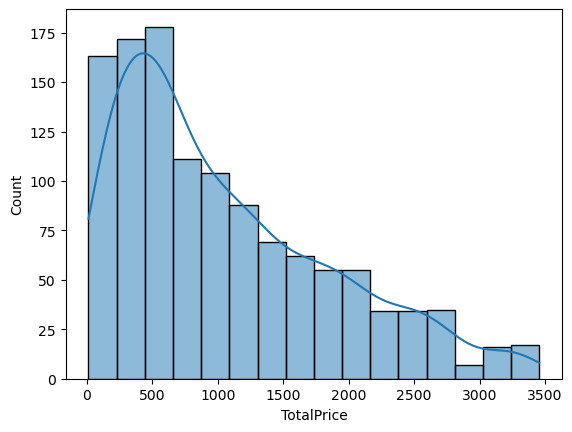

In [10]:
    sns.histplot(df['TotalPrice'], kde=True)
    plt.show()

## Predictive Feature Engineering

Here are new predictive features -

CouponUsed : Identifies whether a customer used a coupon during the purchase.

CartPurchaseRate : Measures how much of the cart items was actually purchased.

OrderQuarter : Captures seasonal and quarterly purchasing patterns(Q1, Q2, Q3, Q4).

In [11]:
# CouponUsed
df['CouponUsed'] = df['CouponCode'].apply(lambda x: 0 if x == 'NoCoupon' else 1)

# CartPurchaseRate
df['CartPurchaseRate'] = (df['Quantity'] / df['ItemsInCart']).round(2)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# OrderQuarter
df['OrderQuarter'] = df['Date'].dt.quarter

In [12]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponUsed,CartPurchaseRate,OrderQuarter
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,0.71,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,1,0.67,3
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,1,0.62,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,1,0.20,4
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,1,0.50,2


## Some Useful Insights

In [13]:
# Coupon Code Usage
used_coupon = (df['CouponCode'] != 'NoCoupon').sum()
no_coupon = (df['CouponCode'] == 'NoCoupon').sum()
print(f"Used Coupon         : {used_coupon}")
print(f"Did Not Use Coupon  : {no_coupon}")

Used Coupon         : 891
Did Not Use Coupon  : 309


In [14]:
# Payment Method
payment_usage = df['PaymentMethod'].value_counts()
print(payment_usage)

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


In [15]:
# Best Seller Products
top_products = (df.groupby('Product')['Quantity'].sum())
top_products.sort_values(ascending=False)
top_products.head(5)

Product
Chair      562
Desk       508
Laptop     535
Monitor    480
Phone      411
Name: Quantity, dtype: int64

In [16]:
# Quater wise total sales
quarter_sales = df.groupby('OrderQuarter')['TotalPrice'].sum()
quarter_sales.sort_values(ascending=False)
for quarter, sales in quarter_sales.items():
    print(f"Q{quarter}: ₹{sales:.2f}")

Q1: ₹360498.94
Q2: ₹414944.77
Q3: ₹241449.50
Q4: ₹247868.75


In [17]:
# Coupon Code Used
coupon_data = df[df['CouponCode'] != 'NoCoupon']
top_coupons = coupon_data['CouponCode'].value_counts()
top_coupons

CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [18]:
df.to_csv("cleaned_dataset.csv", index=False)